
# Week 3: Pediatric ECG Feature Awareness

### Objective
The purpose of this notebook is to build intuition about pediatric ECG features and their biomedical significance without building a diagnostic model. We will analyze the two illustrative ECG records used in Week 2 (`P00001_E01` — CVD and `P04120_E01` — Non-CVD). 
We extract and explain:
1. Heart Rate (HR)
2. RR interval
3. QRS duration


In [2]:

import wfdb
import neurokit2 as nk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Configure plots
plt.rcParams['figure.figsize'] = (15, 6)
plt.style.use('ggplot')

# Ensure output directory exists
os.makedirs('../../Docs/Week3', exist_ok=True)


In [3]:

rec_cvd = 'P00001_E01'
rec_non = 'P04120_E01'

path_cvd = f'../../Child_ECG/Child_ecg/P00/{rec_cvd[:6]}/{rec_cvd}'
path_non = f'../../Child_ECG/Child_ecg/P04/{rec_non[:6]}/{rec_non}'

sig_cvd, meta_cvd = wfdb.rdsamp(path_cvd)
sig_non, meta_non = wfdb.rdsamp(path_non)

fs_cvd = meta_cvd['fs']
fs_non = meta_non['fs']

print(f"CVD Record: {rec_cvd}")
print(f"Sampling Frequency: {fs_cvd} Hz, Channels: {meta_cvd['n_sig']}, Length: {meta_cvd['sig_len']}")
print(f"Comments: {meta_cvd['comments']}")

print(f"\nNon-CVD Record: {rec_non}")
print(f"Sampling Frequency: {fs_non} Hz, Channels: {meta_non['n_sig']}, Length: {meta_non['sig_len']}")
print(f"Comments: {meta_non['comments']}")


CVD Record: P00001_E01
Sampling Frequency: 500 Hz, Channels: 9, Length: 9000
Comments: ['Female 572', 'Ventricular septal defect', 'Left ventricular high voltage;T-wave abnormality']

Non-CVD Record: P04120_E01
Sampling Frequency: 500 Hz, Channels: 12, Length: 10000
Comments: ['Female 4072', 'Otherwise diseases', 'Normal ECG']


### D. Signal preprocessing\nApplying conservative ECG cleaning (e.g. neurokit standard) to Lead II for feature extraction.

In [4]:

# We will use Lead II which is conventionally the best for R-peak detection.
# Lead II index for CVD (9-lead: I, II, III, AVR, AVL, AVF, V1, V3, V5) -> index 1
# Lead II index for Non-CVD (12-lead: I, II, III, aVR, aVL, aVF, V1-V6) -> index 1

lead2_idx_cvd = meta_cvd['sig_name'].index('II')
lead2_idx_non = meta_non['sig_name'].index('II')

ecg_cvd = sig_cvd[:, lead2_idx_cvd]
ecg_non = sig_non[:, lead2_idx_non]

# Clean signals using neurokit
ecg_cvd_clean = nk.ecg_clean(ecg_cvd, sampling_rate=fs_cvd, method="neurokit")
ecg_non_clean = nk.ecg_clean(ecg_non, sampling_rate=fs_non, method="neurokit")


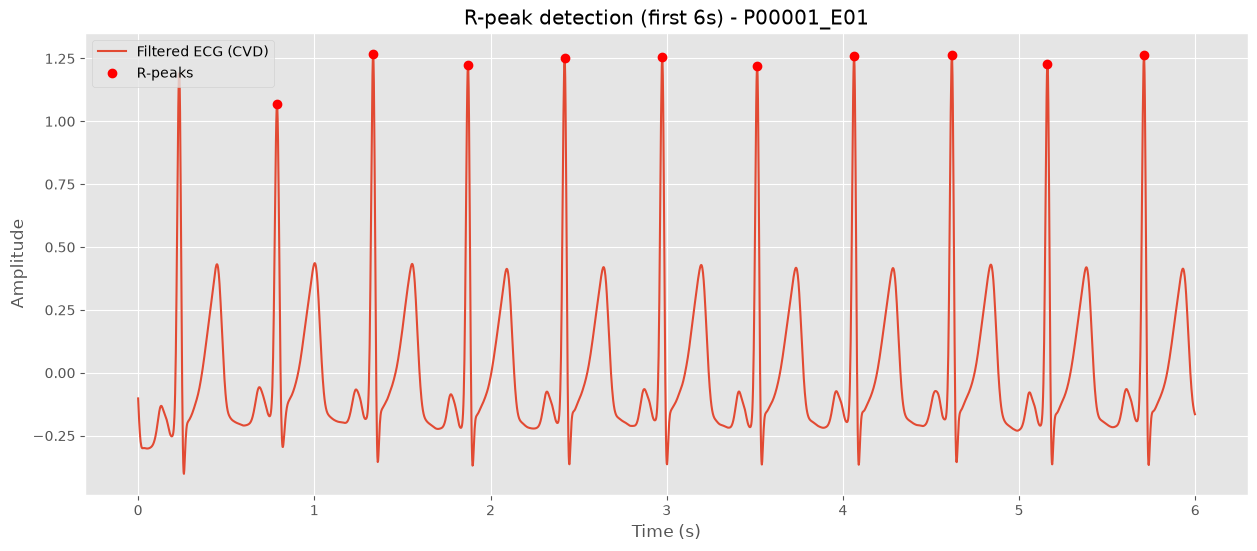

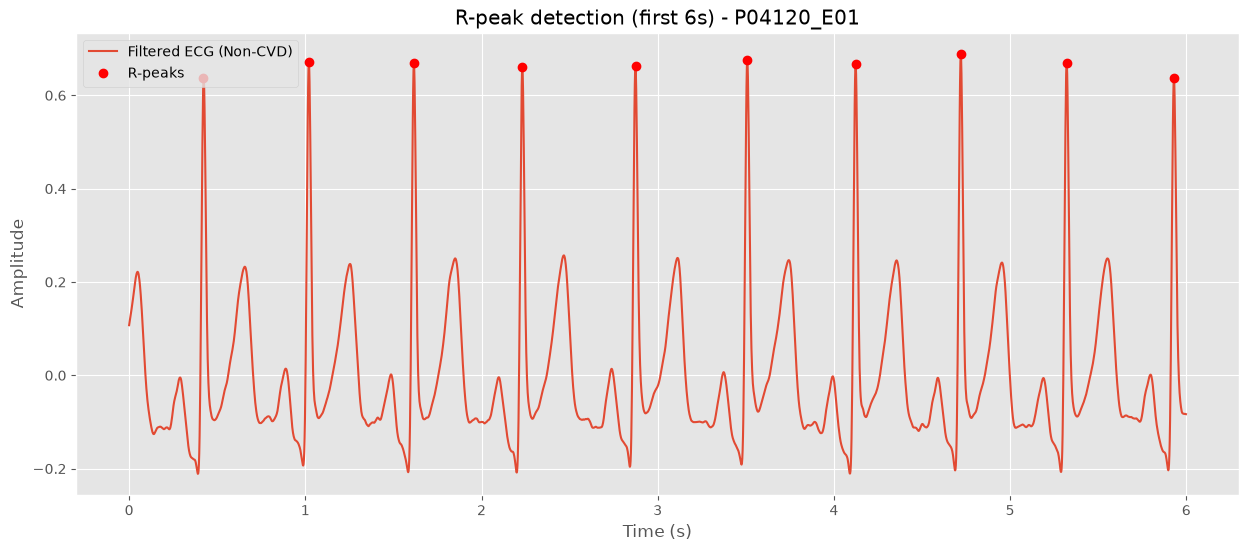

In [5]:

# R-peak detection
_, rpeaks_cvd = nk.ecg_peaks(ecg_cvd_clean, sampling_rate=fs_cvd)
_, rpeaks_non = nk.ecg_peaks(ecg_non_clean, sampling_rate=fs_non)

peaks_cvd = rpeaks_cvd['ECG_R_Peaks']
peaks_non = rpeaks_non['ECG_R_Peaks']

# Filter out false positives at the very start/end if any (conservative)
peaks_cvd = peaks_cvd[(peaks_cvd > 0) & (peaks_cvd < len(ecg_cvd_clean))]
peaks_non = peaks_non[(peaks_non > 0) & (peaks_non < len(ecg_non_clean))]

# Visual check of peaks
plt.figure(figsize=(15, 6))
plt.plot(np.arange(3000)/fs_cvd, ecg_cvd_clean[:3000], label='Filtered ECG (CVD)')
vis_peaks = [p for p in peaks_cvd if p < 3000]
plt.plot(np.array(vis_peaks)/fs_cvd, ecg_cvd_clean[vis_peaks], 'ro', label='R-peaks')
plt.title(f'R-peak detection (first 6s) - {rec_cvd}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

plt.figure(figsize=(15, 6))
plt.plot(np.arange(3000)/fs_non, ecg_non_clean[:3000], label='Filtered ECG (Non-CVD)')
vis_peaks_non = [p for p in peaks_non if p < 3000]
plt.plot(np.array(vis_peaks_non)/fs_non, ecg_non_clean[vis_peaks_non], 'ro', label='R-peaks')
plt.title(f'R-peak detection (first 6s) - {rec_non}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.show()


In [ ]:

def calculate_rr_hr(peaks, fs):
    rr_intervals = np.diff(peaks) / fs
    # Exclude invalid RR intervals (e.g. < 0.2s or > 2.0s for pediatrics, but let's just use >0 filter)
    rr_intervals = rr_intervals[rr_intervals > 0]
    
    mean_rr = np.mean(rr_intervals)
    median_rr = np.median(rr_intervals)
    std_rr = np.std(rr_intervals)
    
    mean_hr = 60 / mean_rr
    median_hr = 60 / median_rr
    
    assert len(rr_intervals) == len(peaks) - 1, "RR intervals count must be exactly one less than R-peaks"
    assert mean_rr > 0, "Mean RR must be positive"
    assert mean_hr > 0, "Mean HR must be positive"
    assert abs((60 / mean_rr) - mean_hr) < 1e-6, "HR must equal 60 / RR"
    
    return {
        'num_beats': len(peaks),
        'mean_rr': mean_rr,
        'median_rr': median_rr,
        'mean_hr': mean_hr,
        'median_hr': median_hr
    }

metrics_cvd = calculate_rr_hr(peaks_cvd, fs_cvd)
metrics_non = calculate_rr_hr(peaks_non, fs_non)

print("CVD Metrics:", metrics_cvd)
print("Non-CVD Metrics:", metrics_non)


CVD Metrics: {'num_beats': 32, 'mean_rr': np.float64(0.5472258064516131), 'median_rr': np.float64(0.548), 'mean_hr': np.float64(109.64395189813719), 'median_hr': np.float64(109.4890510948905)}
Non-CVD Metrics: {'num_beats': 32, 'mean_rr': np.float64(0.6147741935483872), 'median_rr': np.float64(0.616), 'mean_hr': np.float64(97.59680973869239), 'median_hr': np.float64(97.40259740259741)}


In [7]:

def calculate_qrs(ecg_clean, rpeaks, fs):
    # Delineate the ECG signal to find QRS onset and offset
    _, waves_peak = nk.ecg_delineate(ecg_clean, rpeaks, sampling_rate=fs, method="dwt")
    
    qrs_onsets = waves_peak['ECG_R_Onsets']
    qrs_offsets = waves_peak['ECG_R_Offsets']
    
    # Calculate durations where both onset and offset are valid (not NaN)
    valid_durations = []
    for onset, offset in zip(qrs_onsets, qrs_offsets):
        if not np.isnan(onset) and not np.isnan(offset):
            # Duration in seconds
            dur = (offset - onset) / fs
            # QRS must be positive and substantially shorter than RR (~< 0.15s in peds)
            if 0 < dur < 0.20:
                valid_durations.append(dur * 1000) # ms
                
    mean_qrs = np.mean(valid_durations)
    median_qrs = np.median(valid_durations)
    
    return {
        'valid_qrs': len(valid_durations),
        'mean_qrs': mean_qrs,
        'median_qrs': median_qrs,
        'onsets': qrs_onsets,
        'offsets': qrs_offsets
    }

qrs_cvd = calculate_qrs(ecg_cvd_clean, peaks_cvd, fs_cvd)
qrs_non = calculate_qrs(ecg_non_clean, peaks_non, fs_non)

print("CVD QRS (ms):", qrs_cvd['mean_qrs'], "Valid:", qrs_cvd['valid_qrs'])
print("Non-CVD QRS (ms):", qrs_non['mean_qrs'], "Valid:", qrs_non['valid_qrs'])


CVD QRS (ms): 139.14285714285714 Valid: 7
Non-CVD QRS (ms): 122.57142857142857 Valid: 7


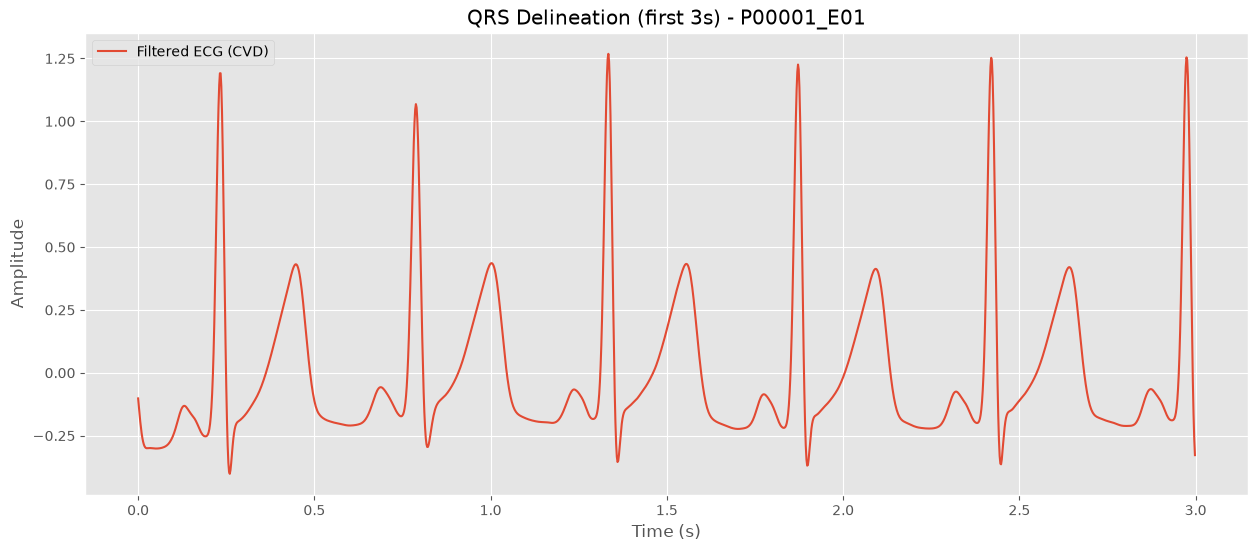

In [8]:

plt.figure(figsize=(15, 6))
plt.plot(np.arange(1500)/fs_cvd, ecg_cvd_clean[:1500], label='Filtered ECG (CVD)')
valid_idx = [i for i, (on, off) in enumerate(zip(qrs_cvd['onsets'], qrs_cvd['offsets'])) if not np.isnan(on) and not np.isnan(off) and off < 1500]
if valid_idx:
    ons = [int(qrs_cvd['onsets'][i]) for i in valid_idx]
    offs = [int(qrs_cvd['offsets'][i]) for i in valid_idx]
    plt.plot(np.array(ons)/fs_cvd, ecg_cvd_clean[ons], 'go', label='QRS Onset')
    plt.plot(np.array(offs)/fs_cvd, ecg_cvd_clean[offs], 'mo', label='QRS Offset')
plt.title(f'QRS Delineation (first 3s) - {rec_cvd}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.show()


In [9]:

# Generate Markdown content for the feature explanation

markdown_content = f"""# Week 3: Pediatric ECG Feature Awareness

## 1. Objective
The purpose of this analysis is to computationally extract specific clinically relevant features (Heart Rate, RR interval, QRS duration) from two illustrative pediatric ECG records and explain their medical significance in the context of pediatric cardiology. **These features are descriptive and this is not a diagnostic model.**

## 2. Records Analyzed
- **CVD-labelled Record (`P00001_E01`)**: 1.5 years old (572 days), Female, diagnosed with Ventricular septal defect.
- **Non-CVD-labelled Record (`P04120_E01`)**: ~11 years old (4072 days), Female, Normal ECG.

*Note: These are illustrative examples. Differences cannot be generalized to the broader populations, and pediatric interpretation is highly age-dependent.*

## 3. Feature Extraction Method
- **ECG Preprocessing**: Lead II was selected and cleaned using NeuroKit2's standard ECG cleaning pipeline.
- **R-peak Detection**: R-peaks were detected using NeuroKit2, and RR intervals calculated from peak-to-peak differences.
- **Heart Rate**: Derived mathematically as `60 / Mean RR`.
- **QRS Duration**: QRS onsets and offsets were delineated using the discrete wavelet transform (`dwt`) method in NeuroKit2. Invalid delineations were excluded.

## 4. Extracted Feature Table

| Record     | Age   | Label   | Mean HR (bpm) | Mean RR (s) | Mean QRS (ms) | Valid Beats (QRS/Total) |
| ---------- | ----- | ------- | ------------: | ----------: | ------------: | ----------------------: |
| {rec_cvd} | 1.5 y | CVD     | {metrics_cvd['mean_hr']:.1f} | {metrics_cvd['mean_rr']:.3f} | {qrs_cvd['mean_qrs']:.1f} | {qrs_cvd['valid_qrs']}/{metrics_cvd['num_beats']} |
| {rec_non} | ~11 y | Non-CVD | {metrics_non['mean_hr']:.1f} | {metrics_non['mean_rr']:.3f} | {qrs_non['mean_qrs']:.1f} | {qrs_non['valid_qrs']}/{metrics_non['num_beats']} |

## 5. Heart Rate — Biomedical Significance
Pediatric resting heart rate is strongly age-dependent. Infants and toddlers normally have a significantly higher resting heart rate compared to older children and adults. 
The observed HR of ~{metrics_cvd['mean_hr']:.0f} bpm for the 1.5-year-old and ~{metrics_non['mean_hr']:.0f} bpm for the 11-year-old are expected physiological variations based on their ages, and should not be judged using adult reference ranges.

## 6. RR Interval — Biomedical Significance
The RR interval represents the time between successive ventricular depolarizations. It is inversely related to heart rate (shorter RR interval = higher HR). 
The 1.5-year-old has a correspondingly shorter mean RR interval (~{metrics_cvd['mean_rr']:.2f} s) than the 11-year-old (~{metrics_non['mean_rr']:.2f} s).

## 7. QRS Duration — Biomedical Significance
The QRS duration represents the approximate duration of ventricular depolarization. Prolonged QRS duration can be associated with intraventricular conduction abnormalities, conduction delay, or ventricular enlargement/hypertrophy in some contexts.
**However**, it is critical to note that QRS duration alone cannot diagnose VSD, ventricular hypertrophy, or CVD. Pediatric normal ranges for QRS duration also increase slightly with age as the heart grows.

## 8. Comparison of the Two Illustrative Records
The CVD record (`P00001_E01`) has a higher heart rate and shorter RR interval, which is primarily explained by the patient's much younger age (1.5 years vs 11 years). 
We cannot present these simple feature differences as proof of disease discrimination or claim causation.

## 9. Verification / Quality Checks
- Automated checks passed: RR > 0, HR > 0, QRS > 0.
- `Mean HR = 60 / Mean RR` mathematically consistent.
- Validated via visual overlay of detected R-peaks and QRS boundaries.

## 10. Limitations
These descriptive features are not diagnostic biomarkers by themselves. Do not use adult ECG normal ranges as pediatric reference values. The two records are not a statistically representative cohort.
"""

with open("../../Docs/Week3/Week3_Feature_Explanation.md", "w") as f:
    f.write(markdown_content)

print("Saved Docs/Week3/Week3_Feature_Explanation.md")


Saved Docs/Week3/Week3_Feature_Explanation.md
